# Runtime and memory by query count

Nested subsets of the bundled assembly, measured with the `curated` and `img` database profiles. Trial 0 is a warm-up and is excluded from the summaries.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'mkdocs.yml').is_file():
            return candidate
    raise FileNotFoundError('could not locate mkdocs.yml')


ROOT = find_project_root(Path.cwd().resolve())
DATA = ROOT / 'docs' / 'data' / 'example_performance.tsv'
FIGURES = ROOT / 'docs' / 'assets' / 'figures'
sys.path.insert(0, str(ROOT / 'notebooks'))
from beautiful_style import finalize_axes, set_beautiful_style

set_beautiful_style(medium='paper', background='light', dpi=180)
plt.rcParams['svg.hashsalt'] = 'ssuextract-docs'
plt.ioff();

In [2]:
measurements = pd.read_csv(DATA, sep='\t')
required = {
    'profile', 'query_sequences', 'total_nucleotides', 'input_sha256',
    'trial', 'warmup', 'elapsed_seconds', 'peak_rss_kb', 'hit_count',
}
assert set(measurements.columns) == required
assert list(measurements['profile'].drop_duplicates()) == ['curated', 'img']
assert list(measurements['query_sequences'].drop_duplicates()) == [1, 10, 100, 1000]
conditions = measurements.groupby(['profile', 'query_sequences'], sort=False)
assert conditions.size().eq(4).all()
assert conditions['warmup'].sum().eq(1).all()
assert conditions['total_nucleotides'].nunique().eq(1).all()
assert conditions['input_sha256'].nunique().eq(1).all()
assert conditions['hit_count'].nunique().eq(1).all()
assert measurements.groupby('query_sequences')['total_nucleotides'].nunique().eq(1).all()
assert measurements.groupby('query_sequences')['input_sha256'].nunique().eq(1).all()
assert measurements['elapsed_seconds'].gt(0).all()
assert measurements['peak_rss_kb'].gt(0).all()
assert measurements['hit_count'].gt(0).all()

measured = measurements.loc[~measurements['warmup']].copy()
measured['peak_rss_gib'] = measured['peak_rss_kb'] / 1024**2
summary = (
    measured.groupby(['profile', 'query_sequences', 'total_nucleotides'], sort=False)
    .agg(
        measured_runs=('trial', 'size'),
        median_seconds=('elapsed_seconds', 'median'),
        median_max_rss_gib=('peak_rss_gib', 'median'),
        accepted_hits=('hit_count', 'first'),
    )
    .reset_index()
)
display(summary.round({'median_seconds': 2, 'median_max_rss_gib': 3}))

,profile,query_sequences,total_nucleotides,measured_runs,median_seconds,median_max_rss_gib,accepted_hits
0,curated,1,113952,3,20.63,0.795,1
1,curated,10,771608,3,49.82,2.605,2
2,curated,100,3846999,3,104.18,2.723,4
3,curated,1000,13254565,3,114.69,2.670,10
4,img,1,113952,3,26.75,0.791,1
5,img,10,771608,3,40.57,2.605,2
6,img,100,3846999,3,101.25,2.724,4
7,img,1000,13254565,3,134.33,2.780,10


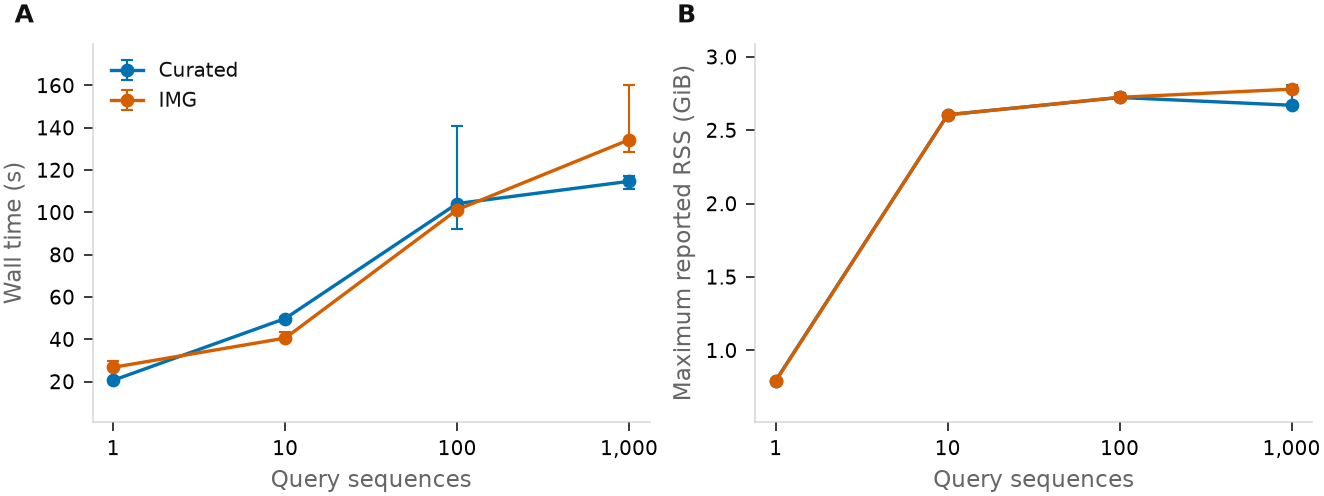

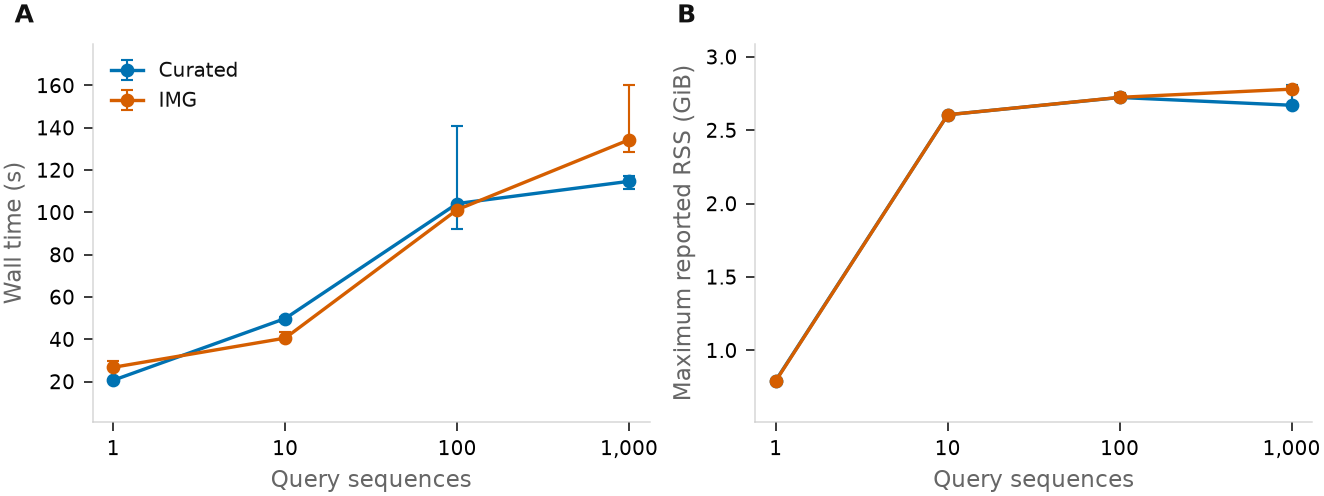

In [3]:
labels = {'curated': 'Curated', 'img': 'IMG'}
colors = {'curated': '#0072B2', 'img': '#D55E00'}
panels = [
    ('elapsed_seconds', 'Wall time (s)'),
    ('peak_rss_gib', 'Maximum reported RSS (GiB)'),
]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.8), constrained_layout=True)
for panel_label, ax, (column, ylabel) in zip(('A', 'B'), axes, panels):
    for profile in labels:
        profile_rows = measured.loc[measured['profile'].eq(profile)]
        grouped = profile_rows.groupby('query_sequences', sort=True)[column]
        medians = grouped.median()
        lower = medians - grouped.min()
        upper = grouped.max() - medians
        ax.errorbar(
            medians.index, medians.values, yerr=np.vstack([lower.values, upper.values]),
            color=colors[profile], label=labels[profile], marker='o', markersize=4.5,
            linewidth=1.35, elinewidth=0.85, capsize=2.2, capthick=0.85, zorder=3,
        )
    ax.set_xscale('log')
    ax.set_xticks([1, 10, 100, 1000], ['1', '10', '100', '1,000'])
    ax.minorticks_off()
    ax.margins(x=0.04, y=0.14)
    finalize_axes(ax, xlabel='Query sequences', ylabel=ylabel)
    ax.text(-0.14, 1.04, panel_label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
axes[0].legend(frameon=False, loc='upper left', fontsize=8, handlelength=1.6)

metadata = {'Date': None, 'Creator': 'SSUextract'}
svg = FIGURES / 'example-performance.svg'
png = FIGURES / 'example-performance.png'
fig.savefig(svg, metadata=metadata)
svg_text = svg.read_text(encoding='utf-8')
svg.write_text('\n'.join(line.rstrip() for line in svg_text.splitlines()) + '\n', encoding='utf-8')
fig.savefig(png, dpi=600, metadata=metadata)
svg.chmod(0o644)
png.chmod(0o644)
fig